# Entregável 3: Análise Estatística Inicial da Base
**Disciplina:** Aquisição de Biossinais
**Autor(es):** José Ferreira Lessa e Matheus Rocha Gomes da Silva
**Data:** Março de 2026

## Objetivo
Este notebook caracteriza estatisticamente o dataset antes de qualquer transformação nos sinais. Vamos verificar se as variáveis seguem distribuição normal, se as variâncias são homogêneas entre as classes diagnósticas, e quais correlações existem. Esses resultados orientam diretamente as escolhas dos entregáveis seguintes — por exemplo, se devemos usar testes paramétricos ou não-paramétricos.

## 1. Importações

In [15]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import scipy.signal as signal
import scipy.stats as stats
from tqdm.notebook import tqdm
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

np.random.seed(42)

## 2. Configurações Globais

In [16]:
PATH_DATA = '../../../data/ptb-xl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/'
FS = 100
N_LEADS = 12
LEAD_NAMES = ['I', 'II', 'III', 'aVL', 'aVR', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
FOLDS_TREINO = [1, 2, 3, 4, 5, 6, 7, 8]
FOLD_VAL = 9
FOLD_TEST = 10

FIGS_DIR = '../figuras/'
os.makedirs(FIGS_DIR, exist_ok=True)
os.makedirs('../outputs', exist_ok=True)

## 3. Carregamento e Filtragem Inicial
Carregamos o CSV com SQI do Entregável 2 e removemos os registros Categoria C (rejeitados por baixa qualidade).

In [17]:
caminho_metadados = '../../entregavel-2/outputs/ptbxl_com_sqi.csv'

if not os.path.exists(caminho_metadados):
    raise FileNotFoundError("Arquivo ptbxl_com_sqi.csv não encontrado. Execute o Entregável 2 primeiro.")

df = pd.read_csv(caminho_metadados, index_col='ecg_id')
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df['diagnostic_superclass'] = df['diagnostic_superclass'].apply(ast.literal_eval)
df['recording_date'] = pd.to_datetime(df['recording_date'], errors='coerce')

tam_original = len(df)
df = df[df['sqi_category'].isin(['A', 'B'])].copy()

display(Markdown(f"Removidos **{tam_original - len(df)}** registros de Categoria C. Trabalhando com **{len(df)}** registros aprovados."))

Removidos **10595** registros de Categoria C. Trabalhando com **11204** registros aprovados.

---
## Seção 1 — Estatística Descritiva dos Metadados

### 1.1 Variáveis Demográficas (Dataset Completo)

**Tabela descritiva: N, média, mediana, desvio padrão, percentis e IQR.**

,count,mean,std,min,5%,25%,50%,75%,95%,max,IQR,Variância
age_clean,11002.0,61.18,16.27,2.0,30.0,52.0,63.0,73.0,84.0,89.0,21.0,264.81
weight,4660.0,71.12,16.33,5.0,48.0,60.0,70.0,80.0,97.0,200.0,20.0,266.59
height,3545.0,166.99,11.04,6.0,152.0,160.0,167.0,175.0,183.0,200.0,15.0,121.85


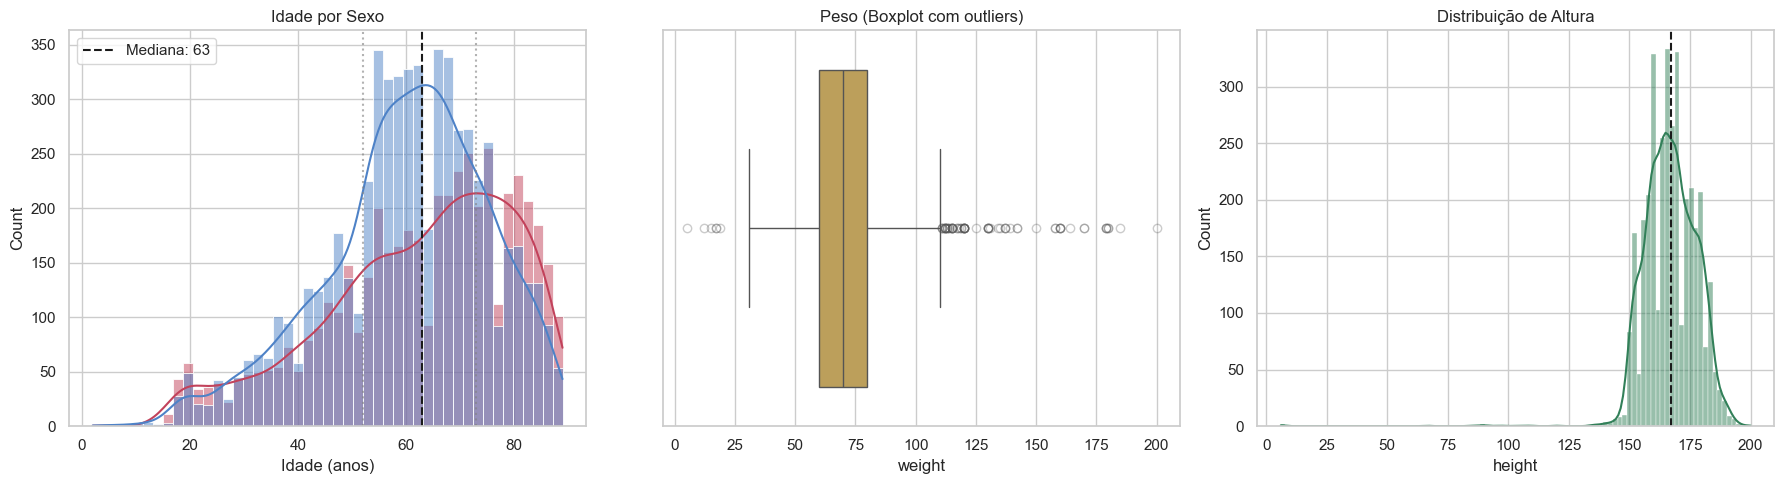

**(Espaço para comentário do aluno — dica: comente sobre a forma das distribuições, presença de outliers em peso/altura, e se a mediana de idade é compatível com um dataset clínico cardíaco.)**

In [18]:
df['age_clean'] = df['age'].replace(300, np.nan)

vars_desc = ['age_clean', 'weight', 'height']
stats_demo = df[vars_desc].describe(percentiles=[0.05, 0.25, 0.75, 0.95]).T
stats_demo['IQR'] = stats_demo['75%'] - stats_demo['25%']
stats_demo['Variância'] = df[vars_desc].var()

display(Markdown("**Tabela descritiva: N, média, mediana, desvio padrão, percentis e IQR.**"))
display(stats_demo.round(2))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x='age_clean', hue='sex', kde=True, ax=axes[0], palette=['#4e82c7', '#c2425b'], alpha=0.5)
axes[0].axvline(df['age_clean'].median(), color='k', linestyle='--', label=f"Mediana: {df['age_clean'].median():.0f}")
axes[0].axvline(df['age_clean'].quantile(0.25), color='gray', linestyle=':', alpha=0.6)
axes[0].axvline(df['age_clean'].quantile(0.75), color='gray', linestyle=':', alpha=0.6)
axes[0].set_title('Idade por Sexo')
axes[0].set_xlabel('Idade (anos)')
axes[0].legend()

sns.boxplot(data=df, x='weight', color='#cca64b', ax=axes[1],
            flierprops={'marker': 'o', 'color': 'r', 'alpha': 0.3})
axes[1].set_title('Peso (Boxplot com outliers)')

sns.histplot(data=df, x='height', kde=True, ax=axes[2], color='#328059', alpha=0.5)
axes[2].axvline(df['height'].median(), color='k', linestyle='--')
axes[2].set_title('Distribuição de Altura')

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'descritiva_demografica.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: comente sobre a forma das distribuições, presença de outliers em peso/altura, e se a mediana de idade é compatível com um dataset clínico cardíaco.)**"))

### 1.2 Variáveis Demográficas por Superclasse Diagnóstica
Para evitar ambiguidade do multi-label, selecionamos apenas registros com exatamente 1 superclasse.

**Estatísticas separadas por diagnóstico:**

age_clean             weight             height             
                median  mean   std median  mean   std median   mean   std
single_class                                                             
CD                67.0  65.3  14.6   70.0  71.5  15.1  168.0  167.7  12.1
HYP               66.0  62.6  17.0   70.0  68.7  14.3  168.0  166.2   9.7
MI                65.0  64.7  12.9   72.0  72.5  16.2  168.0  166.7   9.6
NORM              54.0  53.0  16.9   70.0  71.9  15.6  167.0  167.2  11.0
STTC              68.0  66.3  13.8   68.0  69.7  16.1  165.0  165.3   9.9

C:\Users\josel\AppData\Local\Temp\ipykernel_17924\81950606.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_single, x='single_class', y='age_clean',


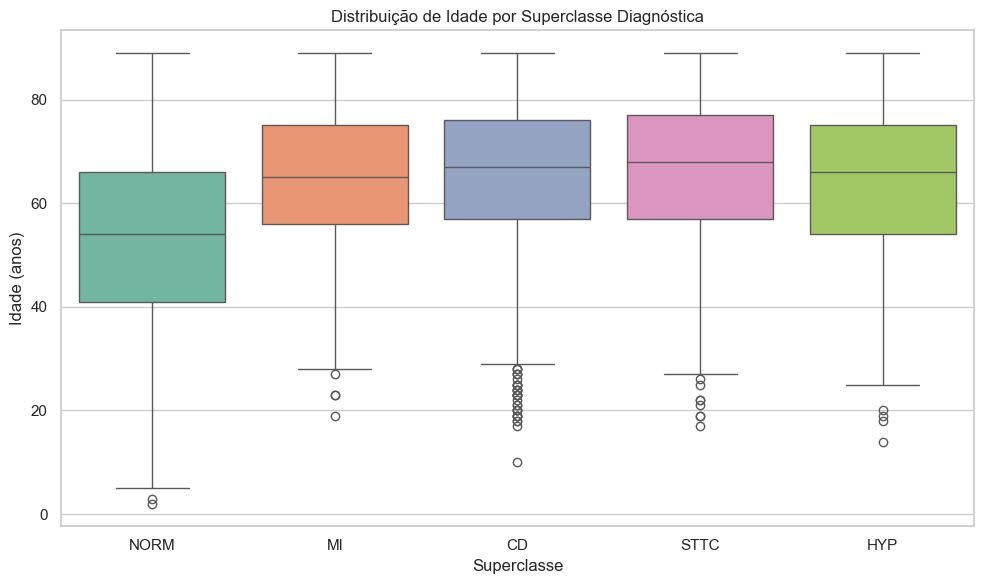

**(Espaço para comentário do aluno — dica: MI e HYP tendem a ter medianas de idade mais altas? Isso faz sentido clínico? A aterosclerose é progressiva com a idade.)**

In [19]:
df_single = df[df['n_superclasses'] == 1].copy()
df_single['single_class'] = df_single['diagnostic_superclass'].apply(lambda x: x[0])
classes_target = ['NORM', 'MI', 'CD', 'STTC', 'HYP']

pivot_diag = df_single.groupby('single_class')[vars_desc].agg(['median', 'mean', 'std'])
display(Markdown("**Estatísticas separadas por diagnóstico:**"))
display(pivot_diag.round(1))

fig = plt.figure(figsize=(10, 6))
sns.boxplot(data=df_single, x='single_class', y='age_clean',
            order=classes_target, palette='Set2')
plt.title('Distribuição de Idade por Superclasse Diagnóstica')
plt.xlabel('Superclasse')
plt.ylabel('Idade (anos)')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'idade_por_superclasse.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: MI e HYP tendem a ter medianas de idade mais altas? Isso faz sentido clínico? A aterosclerose é progressiva com a idade.)**"))

### 1.3 Distribuição Temporal dos Registros

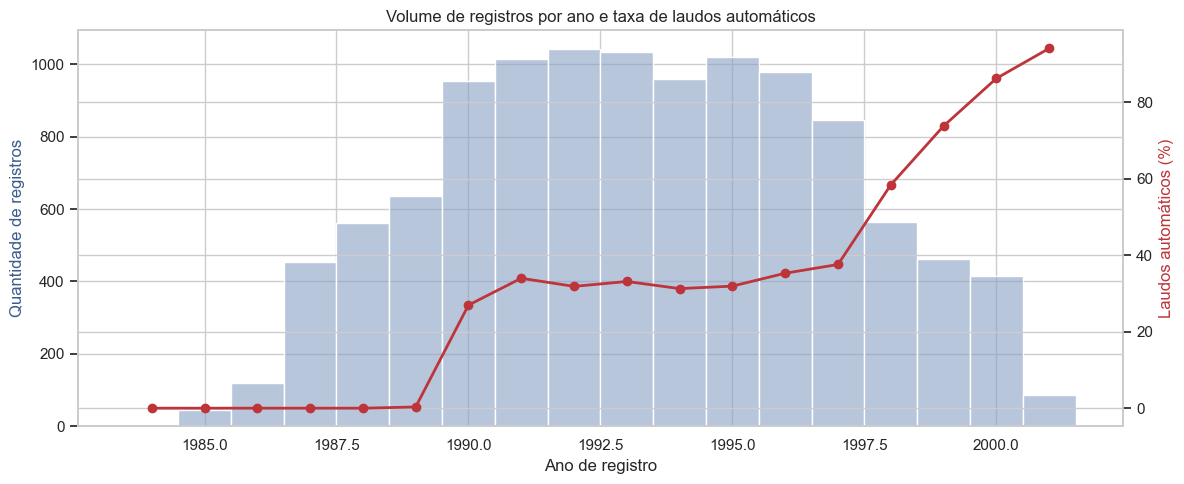

**(Espaço para comentário do aluno — dica: observe se houve crescimento no uso de laudos automáticos ao longo dos anos, e se o volume de registros variou significativamente.)**

In [20]:
df['recording_year'] = df['recording_date'].dt.year

fig, ax1 = plt.subplots(figsize=(12, 5))

anos = df['recording_year'].dropna().astype(int)
sns.histplot(x=anos, discrete=True, color='#8aa1c4', ax=ax1, alpha=0.6)
ax1.set_xlabel('Ano de registro')
ax1.set_ylabel('Quantidade de registros', color='#3a5c8c')

ax2 = ax1.twinx()
taxa_auto = df.groupby('recording_year')['initial_autogenerated_report'].mean() * 100
ax2.plot(taxa_auto.index, taxa_auto.values, color='#bd353a', marker='o', linewidth=2)
ax2.set_ylabel('Laudos automáticos (%)', color='#bd353a')

plt.title('Volume de registros por ano e taxa de laudos automáticos')
plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'temporal_coletas.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: observe se houve crescimento no uso de laudos automáticos ao longo dos anos, e se o volume de registros variou significativamente.)**"))

---
## Seção 2 — Estatística Descritiva dos Sinais

Carregamos uma amostra estratificada de 500 registros (100 por superclasse, SQI A, folds de treino) para calcular métricas de amplitude por derivação.

In [21]:
def load_ecg(ecg_id, dataframe, path_base, fs=100):
    linha = dataframe.loc[ecg_id]
    file_target = linha['filename_lr'] if fs == 100 else linha['filename_hr']
    signal_arr, _ = wfdb.rdsamp(os.path.join(path_base, file_target))
    return signal_arr

# Amostragem estratificada
df_a_puros = df_single[(df_single['sqi_category'] == 'A') & (df_single['strat_fold'].isin(FOLDS_TREINO))]

ids_amostra = []
for c in classes_target:
    pool = df_a_puros[df_a_puros['single_class'] == c]
    n = min(len(pool), 100)
    if n > 0:
        ids_amostra.extend(pool.sample(n, random_state=42).index)

display(Markdown(f"Carregando sinais de **{len(ids_amostra)}** registros amostrados..."))

resultados_amp = []
energias = []
cats = []

for eid in tqdm(ids_amostra, desc='Extraindo métricas de amplitude'):
    sig = load_ecg(eid, df, PATH_DATA, FS)
    s_rms = np.sqrt(np.mean(sig**2, axis=0))
    s_p2p = np.max(sig, axis=0) - np.min(sig, axis=0)
    cat = df_single.loc[eid, 'single_class']

    energias.append(np.sum(sig**2) / len(sig))
    cats.append(cat)

    for c_id, lead in enumerate(LEAD_NAMES):
        resultados_amp.append({
            'ecg_id': eid, 'lead': lead, 'class': cat,
            'rms': s_rms[c_id], 'p2p': s_p2p[c_id]
        })

df_amp = pd.DataFrame(resultados_amp)
df_energ = pd.DataFrame({'ecg_id': ids_amostra, 'energia': energias, 'class': cats})

Carregando sinais de **429** registros amostrados...

Extraindo métricas de amplitude:   0%|          | 0/429 [00:00<?, ?it/s]

### 2.1 Amplitude RMS por Derivação e Superclasse

C:\Users\josel\AppData\Local\Temp\ipykernel_17924\4286061822.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_energ, x='class', y='energia', order=classes_target, ax=ax2, palette='magma')


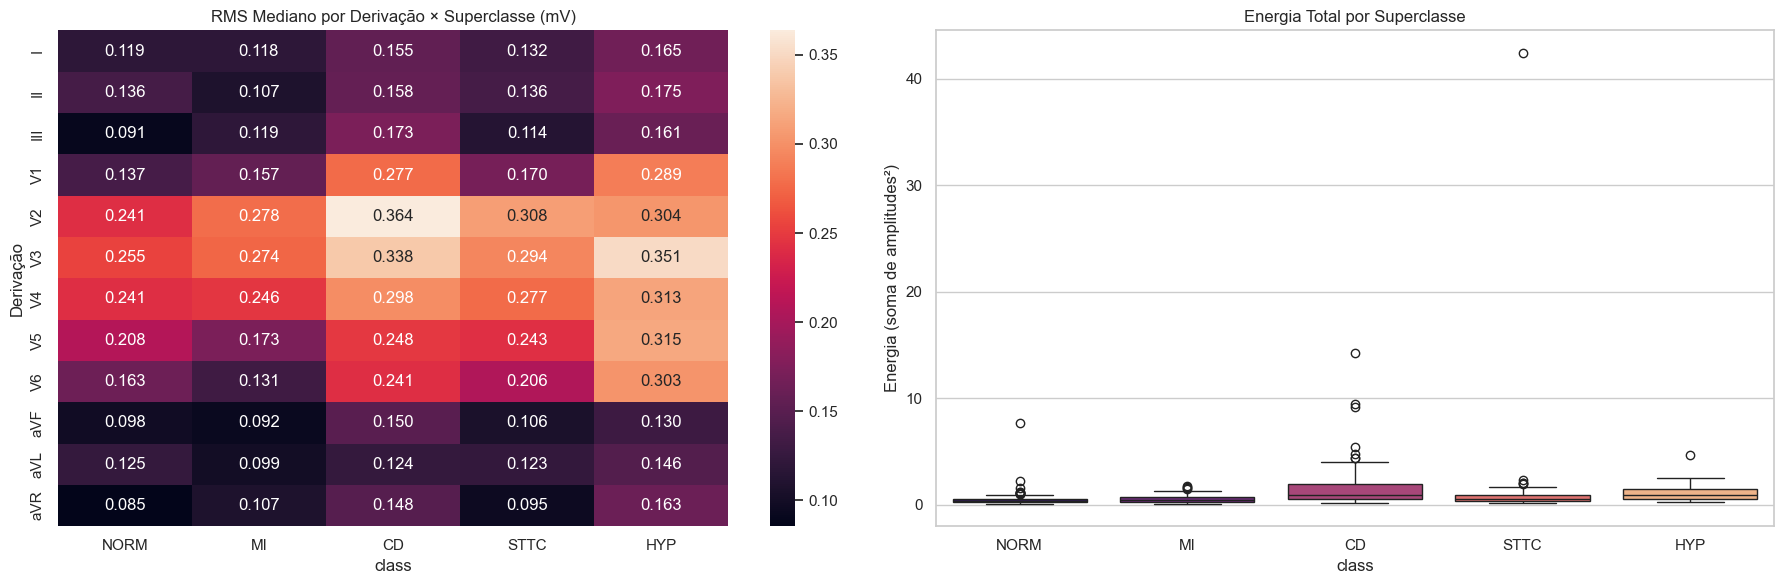

**(Espaço para comentário do aluno — dica: identifique quais derivações têm maior RMS para cada patologia. V2-V3 costumam ser mais energéticas por estarem próximas ao coração. MI inferior deve mostrar maior atividade em II, III, aVF.)**

In [22]:
pivot_rms = df_amp.groupby(['lead', 'class'])['rms'].median().unstack()[classes_target]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(pivot_rms, annot=True, cmap='rocket', fmt=".3f", ax=ax1)
ax1.set_title('RMS Mediano por Derivação × Superclasse (mV)')
ax1.set_ylabel('Derivação')

sns.boxplot(data=df_energ, x='class', y='energia', order=classes_target, ax=ax2, palette='magma')
ax2.set_title('Energia Total por Superclasse')
ax2.set_ylabel('Energia (soma de amplitudes²)')

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'rms_energia_superclasse.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: identifique quais derivações têm maior RMS para cada patologia. V2-V3 costumam ser mais energéticas por estarem próximas ao coração. MI inferior deve mostrar maior atividade em II, III, aVF.)**"))

---
## Seção 3 — Testes de Normalidade

### 3.1 Shapiro-Wilk e Kolmogorov-Smirnov
Aplicamos ambos os testes em subamostras das variáveis de interesse. O Shapiro-Wilk é mais poderoso para amostras menores, enquanto o K-S é mais apropriado para amostras grandes.

In [23]:
amostra_v = df[['age_clean', 'weight', 'height']].dropna().sample(n=min(500, len(df)), random_state=42)

vars_teste = {
    'Idade': amostra_v['age_clean'].values,
    'Peso': amostra_v['weight'].dropna().values,
    'Altura': amostra_v['height'].dropna().values,
    'RMS DII': df_amp[df_amp['lead'] == 'II']['rms'].values,
    'Energia total': df_energ['energia'].values
}

linhas_teste = []
for nome, valores in vars_teste.items():
    v = valores[~np.isnan(valores)]
    if len(v) < 3:
        continue
    stat_sw, p_sw = stats.shapiro(v[:5000])  # Shapiro tem limite prático
    stat_ks, p_ks = stats.kstest(v, 'norm', args=(np.mean(v), np.std(v)))

    linhas_teste.append({
        'Variável': nome,
        'Shapiro W': round(stat_sw, 4),
        'p (SW)': "< 0.001" if p_sw < 0.001 else round(p_sw, 4),
        'Rejeita normalidade (SW)?': "Sim" if p_sw < 0.05 else "Não",
        'K-S stat': round(stat_ks, 4),
        'p (K-S)': "< 0.001" if p_ks < 0.001 else round(p_ks, 4),
        'Rejeita normalidade (K-S)?': "Sim" if p_ks < 0.05 else "Não"
    })

df_testes_norm = pd.DataFrame(linhas_teste).set_index('Variável')
display(df_testes_norm)

,Shapiro W,p (SW),Rejeita normalidade (SW)?,K-S stat,p (K-S),Rejeita normalidade (K-S)?
Variável,,,,,,
Idade,0.9316,< 0.001,Sim,0.1144,< 0.001,Sim
Peso,0.9874,< 0.001,Sim,0.0512,0.1407,Não
Altura,0.9819,< 0.001,Sim,0.0824,0.0021,Sim
RMS DII,0.9228,< 0.001,Sim,0.0997,< 0.001,Sim
Energia total,0.2219,< 0.001,Sim,0.3568,< 0.001,Sim


### 3.2 Q-Q Plots

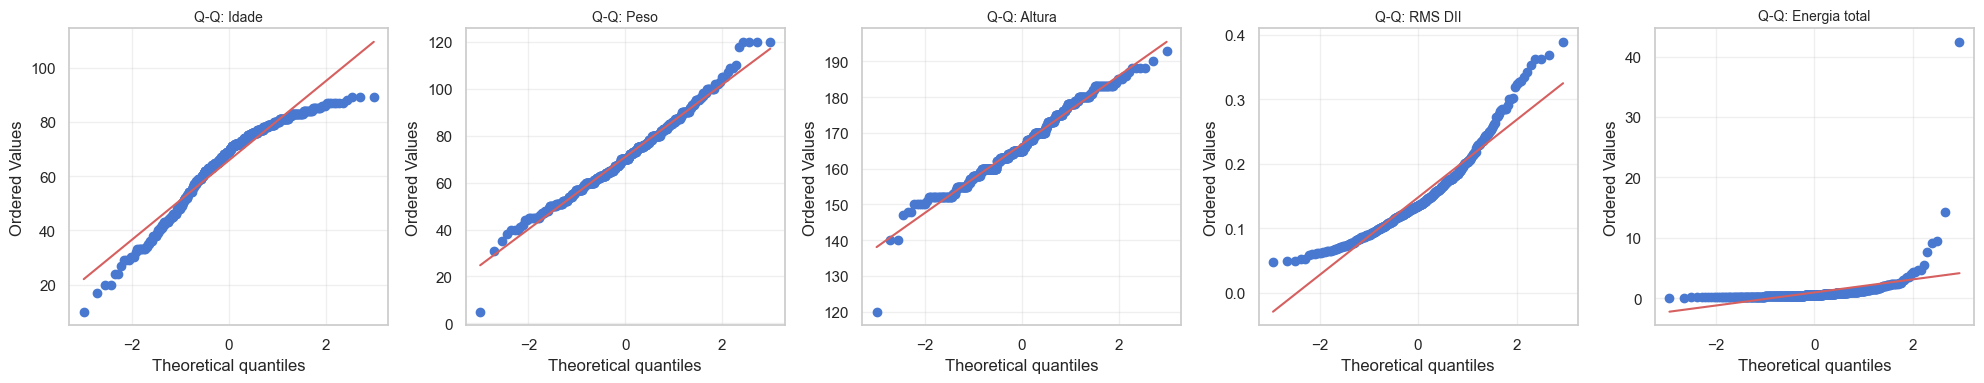

**(Espaço para comentário do aluno — dica: desvios nas pontas do Q-Q indicam caudas pesadas. Se todas as variáveis rejeitam normalidade, isso justifica o uso de testes não-paramétricos nos próximos entregáveis.)**

In [24]:
fig, axes = plt.subplots(1, len(vars_teste), figsize=(4 * len(vars_teste), 4))

for i, (nome, valores) in enumerate(vars_teste.items()):
    v = valores[~np.isnan(valores)]
    stats.probplot(v, dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q: {nome}', fontsize=10)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'qq_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: desvios nas pontas do Q-Q indicam caudas pesadas. Se todas as variáveis rejeitam normalidade, isso justifica o uso de testes não-paramétricos nos próximos entregáveis.)**"))

---
## Seção 4 — Testes de Homocedasticidade

### 4.1 Levene e Bartlett
O teste de Levene (baseado na mediana) é robusto a não-normalidade. O de Bartlett assume normalidade. Ambos testam se as variâncias são iguais entre os grupos diagnósticos.

In [25]:
grupos_idade = [df_single[df_single['single_class'] == c]['age_clean'].dropna() for c in classes_target]
grupos_energ = [df_energ[df_energ['class'] == c]['energia'].dropna() for c in classes_target]
grupos_rms = [df_amp[(df_amp['lead'] == 'II') & (df_amp['class'] == c)]['rms'].dropna() for c in classes_target]

linhas_h = []
metricas = {'Idade': grupos_idade, 'Energia total': grupos_energ, 'RMS DII': grupos_rms}

for nome, grupos in metricas.items():
    stat_l, p_l = stats.levene(*grupos, center='median')
    stat_b, p_b = stats.bartlett(*grupos)
    linhas_h.append({
        'Variável': nome,
        'Levene p-valor': "< 0.001" if p_l < 0.001 else round(p_l, 4),
        'Homocedástica (Levene)?': 'Não' if p_l < 0.05 else 'Sim',
        'Bartlett p-valor': "< 0.001" if p_b < 0.001 else round(p_b, 4),
        'Homocedástica (Bartlett)?': 'Não' if p_b < 0.05 else 'Sim'
    })

df_hetero = pd.DataFrame(linhas_h).set_index('Variável')
display(df_hetero)

,Levene p-valor,Homocedástica (Levene)?,Bartlett p-valor,Homocedástica (Bartlett)?
Variável,,,,
Idade,< 0.001,Não,< 0.001,Não
Energia total,0.0648,Sim,< 0.001,Não
RMS DII,0.0048,Não,< 0.001,Não


### 4.2 Decisão Metodológica
Com base nos testes acima, montamos a tabela-decisão que será referenciada nos próximos entregáveis.

In [26]:
# Gerando tabela-decisão dinamicamente a partir dos resultados dos testes
linhas_decisao = []

for var in df_testes_norm.index:
    # Normalidade: rejeita se Shapiro-Wilk diz "Sim" (rejeita normalidade)
    eh_normal = df_testes_norm.loc[var, 'Rejeita normalidade (SW)?'] == 'Não'

    # Homocedasticidade (se a variável foi testada)
    if var in df_hetero.index:
        eh_homo = df_hetero.loc[var, 'Homocedástica (Levene)?'] == 'Sim'
    else:
        eh_homo = None

    str_normal = 'Sim' if eh_normal else 'Não'
    str_homo = 'Sim' if eh_homo else ('A verificar' if eh_homo is None else 'Não')

    if eh_normal and (eh_homo is None or eh_homo):
        teste_k = 'ANOVA'
        teste_2 = 't-test'
    else:
        teste_k = 'Kruskal-Wallis'
        teste_2 = 'Mann-Whitney U'

    linhas_decisao.append({
        'Variável': var,
        'Normal?': str_normal,
        'Homocedástica?': str_homo,
        'Teste para K grupos': teste_k,
        'Teste para 2 grupos': teste_2
    })

df_decisao = pd.DataFrame(linhas_decisao).set_index('Variável')

display(Markdown("**Tabela-decisão gerada a partir dos testes:**"))
display(df_decisao)

# Conclusão automática
n_nao_normais = sum(1 for l in linhas_decisao if l['Normal?'] == 'Não')
total_vars = len(linhas_decisao)

if n_nao_normais >= total_vars // 2:
    display(Markdown(f"**Conclusão:** {n_nao_normais} de {total_vars} variáveis rejeitaram normalidade. Como a maioria não é normal e as variâncias diferem entre classes, devemos usar **testes não-paramétricos** (Kruskal-Wallis, Mann-Whitney, Wilcoxon) nas comparações dos entregáveis 4 e 9."))
else:
    display(Markdown(f"**Conclusão:** {n_nao_normais} de {total_vars} variáveis rejeitaram normalidade. Testes paramétricos podem ser usados para as variáveis normais, mas por consistência recomenda-se usar não-paramétricos em todo o pipeline."))

display(Markdown("**(Espaço para comentário do aluno — dica: explique por que a não-normalidade e heterocedasticidade inviabilizam ANOVA e t-test tradicionais, e justifique a escolha por Kruskal-Wallis/Mann-Whitney.)**"))

**Tabela-decisão gerada a partir dos testes:**

,Normal?,Homocedástica?,Teste para K grupos,Teste para 2 grupos
Variável,,,,
Idade,Não,Não,Kruskal-Wallis,Mann-Whitney U
Peso,Não,A verificar,Kruskal-Wallis,Mann-Whitney U
Altura,Não,A verificar,Kruskal-Wallis,Mann-Whitney U
RMS DII,Não,Não,Kruskal-Wallis,Mann-Whitney U
Energia total,Não,Sim,Kruskal-Wallis,Mann-Whitney U


**Conclusão:** 5 de 5 variáveis rejeitaram normalidade. Como a maioria não é normal e as variâncias diferem entre classes, devemos usar **testes não-paramétricos** (Kruskal-Wallis, Mann-Whitney, Wilcoxon) nas comparações dos entregáveis 4 e 9.

**(Espaço para comentário do aluno — dica: explique por que a não-normalidade e heterocedasticidade inviabilizam ANOVA e t-test tradicionais, e justifique a escolha por Kruskal-Wallis/Mann-Whitney.)**

---
## Seção 5 — Análise de Correlação

### 5.1 Matrizes de Pearson e Spearman

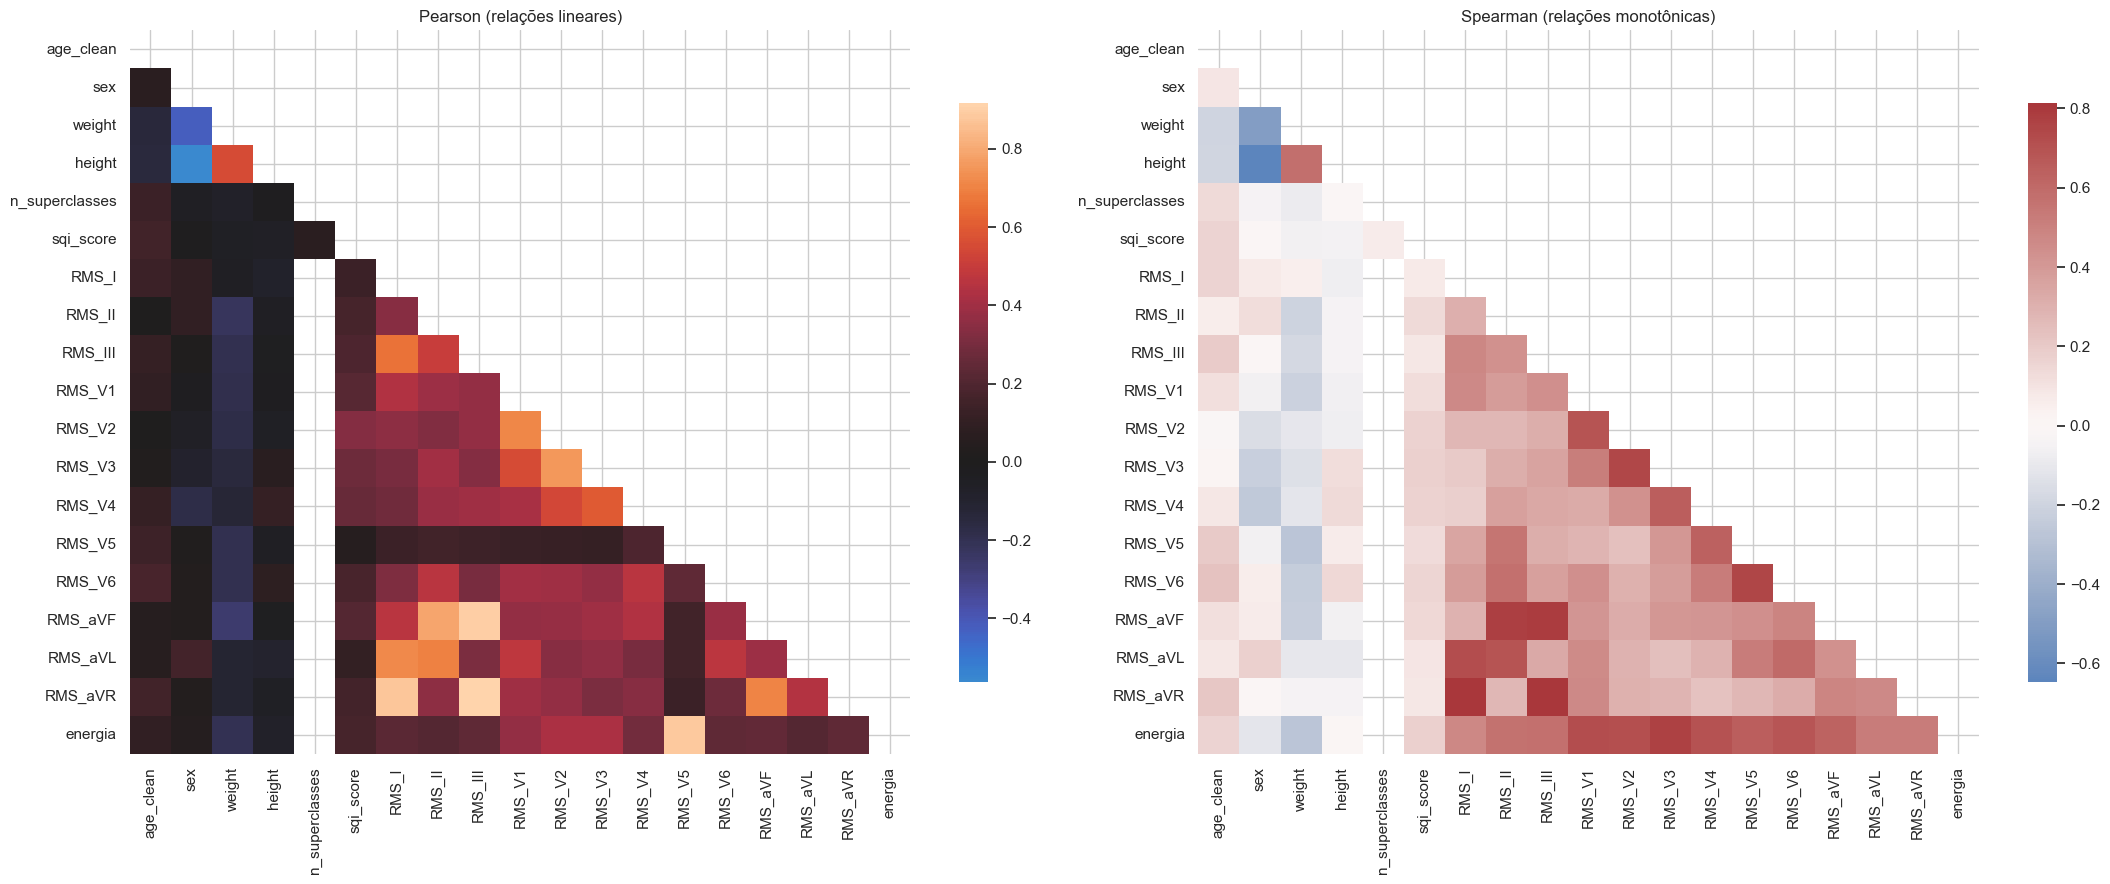

**(Espaço para comentário do aluno — dica: procure pares com correlação forte (|r| > 0.7). RMS de derivações adjacentes (V1-V2) tendem a ser altamente correlacionadas por proximidade anatômica. A relação idade × n_superclasses é clinicamente esperada.)**

In [27]:
df_corr_base = df[['age_clean', 'sex', 'weight', 'height', 'n_superclasses', 'sqi_score']].copy()

# Adicionando RMS pivotado dos 500 registros amostrados
df_rms_pivot = df_amp.pivot(index='ecg_id', columns='lead', values='rms')
df_rms_pivot = df_rms_pivot.rename(columns={l: f'RMS_{l}' for l in LEAD_NAMES})

df_corr = df_corr_base.join(df_rms_pivot).join(df_energ.set_index('ecg_id')['energia'])

corr_p = df_corr.corr(method='pearson')
corr_s = df_corr.corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(22, 9))

mask = np.triu(np.ones_like(corr_p, dtype=bool))
sns.heatmap(corr_p, mask=mask, cmap='icefire', center=0, ax=axes[0], annot=False, cbar_kws={'shrink': .8})
axes[0].set_title('Pearson (relações lineares)')

sns.heatmap(corr_s, mask=mask, cmap='vlag', center=0, ax=axes[1], annot=False, cbar_kws={'shrink': .8})
axes[1].set_title('Spearman (relações monotônicas)')

plt.tight_layout()
fig.savefig(os.path.join(FIGS_DIR, 'correlacoes_pearson_spearman.png'), dpi=150, bbox_inches='tight')
plt.show()

display(Markdown("**(Espaço para comentário do aluno — dica: procure pares com correlação forte (|r| > 0.7). RMS de derivações adjacentes (V1-V2) tendem a ser altamente correlacionadas por proximidade anatômica. A relação idade × n_superclasses é clinicamente esperada.)**"))

---
## Seção 6 — Síntese e Salvamento

**(Espaço para comentário do aluno — dica: resuma as principais conclusões: quais variáveis são normais ou não, quais têm variâncias homogêneas, quais correlações fortes foram encontradas, e como isso impacta as decisões dos entregáveis seguintes.)**

In [28]:
path_estat = '../outputs/estatistica_inicial_resultados.csv'

df_export = pd.concat([df_testes_norm, df_hetero], axis=1)
df_export.to_csv(path_estat)

display(Markdown(f"""
**Arquivo salvo:** `{path_estat}`

Os resultados dos testes de normalidade e homocedasticidade foram exportados. A principal conclusão é que as variáveis do dataset **não seguem distribuição normal**, o que direciona o uso de testes não-paramétricos nos entregáveis subsequentes.
"""))


**Arquivo salvo:** `../outputs/estatistica_inicial_resultados.csv`

Os resultados dos testes de normalidade e homocedasticidade foram exportados. A principal conclusão é que as variáveis do dataset **não seguem distribuição normal**, o que direciona o uso de testes não-paramétricos nos entregáveis subsequentes.
